In [1]:
#sarinakasaiyan
#1403/11/11

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
# در ابتدای اسکریپت، بعد از import‌ها
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Add
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [3]:
from google.colab import drive
drive.mount('/content/drive')

# تعریف مسیرها
resized_images_dir = '/content/drive/MyDrive/braintumors/resized_images'
label_file = '/content/drive/MyDrive/braintumors/Label_updated-2.csv'

Mounted at /content/drive


In [4]:
# تعریف انواع تومورها
TUMOR_TYPES = {
    1: "Meningioma",
    2: "Glioma",
    3: "Pituitary Tumor"
}


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout, BatchNormalization, Flatten, Dense, Add, LeakyReLU, GlobalAveragePooling2D, multiply
from tensorflow.keras.regularizers import l2

def attention_block(x, g, inter_channel):
    theta_x = Conv2D(inter_channel, 1, use_bias=False)(x)
    phi_g = Conv2D(inter_channel, 1, use_bias=False)(g)
    f = LeakyReLU(0.2)(Add()([theta_x, phi_g]))
    psi_f = Conv2D(1, 1, use_bias=False)(f)
    rate = LeakyReLU(0.2)(psi_f)
    att_x = multiply([x, rate])
    return att_x


def conv_block(x, filters, kernel_size=3):
    x = Conv2D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)
    x = Conv2D(filters, kernel_size, padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.2)(x)
    return x




def build_unet(input_size=(128, 128, 3), num_classes=3):
    inputs = Input(input_size)

    # Encoder
    conv1 = conv_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = conv_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = conv_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bridge
    conv4 = conv_block(pool3, 512)
    drop4 = Dropout(0.5)(conv4)

    # Decoder
    up5 = UpSampling2D(size=(2, 2))(drop4)
    att5 = attention_block(conv3, up5, 128)
    up5 = concatenate([up5, att5])
    conv5 = conv_block(up5, 256)

    up6 = UpSampling2D(size=(2, 2))(conv5)
    att6 = attention_block(conv2, up6, 64)
    up6 = concatenate([up6, att6])
    conv6 = conv_block(up6, 128)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    att7 = attention_block(conv1, up7, 32)
    up7 = concatenate([up7, att7])
    conv7 = conv_block(up7, 64)

    # Final layers for classification
    gap = GlobalAveragePooling2D()(conv7)
    outputs = Dense(num_classes, activation='softmax', kernel_regularizer=l2(1e-4))(gap)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# استفاده از مدل
model = build_unet(input_size=(128, 128, 3), num_classes=3)


In [6]:
model = build_unet(input_size=(128, 128, 3), num_classes=3)


In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

# بارگذاری داده‌ها
df = pd.read_csv(label_file)

images = []
labels = []

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Loading Images"):
    filename = row['ID']
    img_path = os.path.join(resized_images_dir, filename)

    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, (128, 128))  # تغییر اینجا
        images.append(img_resized)
        labels.append(row['label'])

X = np.array(images) / 255.0

# تبدیل برچسب‌های متنی به عددی
le = LabelEncoder()
y_numeric = le.fit_transform(np.array(labels))


Loading Images:  39%|███▉      | 1207/3064 [11:09<17:13,  1.80it/s]

In [ ]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_1 (Cast)             │ (None, 128, 128, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ cast_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 128, 128, 64)   │            256 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_20            │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ leaky_re_lu_20[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_15    │ (None, 128, 128, 64)   │            256 │ conv2d_24[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_21            │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 64, 64, 64)     │              0 │ leaky_re_lu_21[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 64, 64, 128)    │            512 │ conv2d_25[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_22            │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ leaky_re_lu_22[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 64, 64, 128)    │            512 │ conv2d_26[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_23            │ (None, 64, 64, 128)    │              0 │ batch_normalization_1… │
│ (LeakyReLU)          

 Total params: 7,923,555 (30.23 MB)

 Trainable params: 7,917,923 (30.20 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:
def preprocess_image(img):
    # نرمال‌سازی کنتراست
    img_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

    # اعمال CLAHE برای بهبود کیفیت
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = clahe.apply(img_normalized)

    return img_enhanced

def show_sample_images(X, y, num_samples=4, num_categories=3):
    tumor_types = ["Meningioma", "Glioma", "Pituitary Tumor"]
    colors = ['red', 'green', 'blue']

    fig, axes = plt.subplots(num_categories, num_samples, figsize=(num_samples*4, num_categories*4))

    for i, tumor_type in enumerate(tumor_types):
        indices = np.where(y == i)[0]

        for j in range(num_samples):
            sample_index = random.choice(indices)
            img = X[sample_index]

            # پردازش تصویر
            img_processed = preprocess_image(img)

            axes[i, j].imshow(img_processed, cmap='gray')

            if j == 0:
                axes[i, j].set_title(tumor_type, fontsize=12, color=colors[i])

            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()


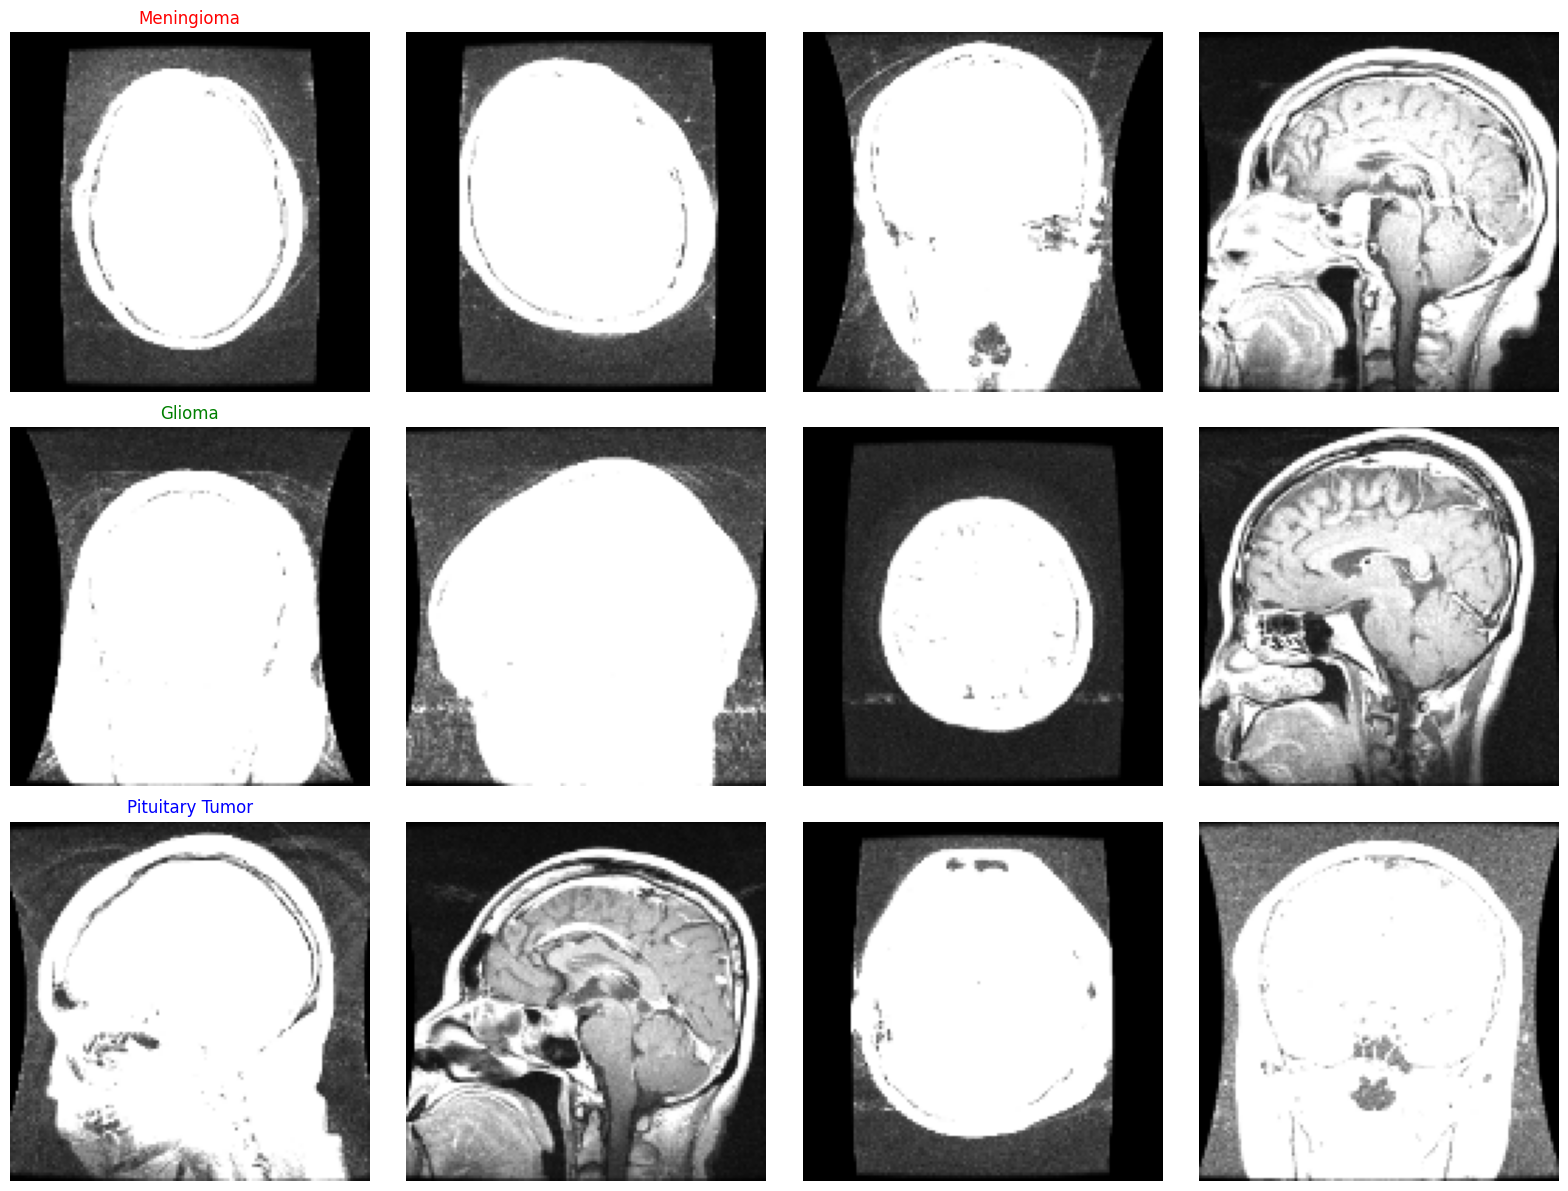

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def show_sample_images(X, y, num_samples=4, num_categories=3):
    # لیست انواع تومور
    tumor_types = ["Meningioma", "Glioma", "Pituitary Tumor"]

    # رنگ‌های مختلف برای هر دسته
    colors = ['red', 'green', 'blue']

    # تعداد ردیف و ستون برای نمایش
    num_rows = num_categories
    num_cols = num_samples

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*4, num_rows*4))

    for i, tumor_type in enumerate(tumor_types):
        # پیدا کردن همه ایندکس‌های مربوط به این نوع تومور
        indices = np.where(y == i)[0]

        if len(indices) == 0:
            print(f"هیچ نمونه‌ای برای {tumor_type} یافت نشد.")
            continue

        for j in range(num_samples):
            # انتخاب یک نمونه تصادفی
            sample_index = random.choice(indices)

            # نمایش تصویر
            img = X[sample_index]
            if len(img.shape) == 2:  # اگر تصویر سیاه و سفید است
                img = np.stack((img,)*3, axis=-1)  # تبدیل به RGB
            axes[i, j].imshow(img)
            if j == 0:  # فقط برای اولین تصویر در هر ردیف عنوان را نمایش می‌دهیم
                axes[i, j].set_title(tumor_type, fontsize=12, color=colors[i])
            axes[i, j].axis('off')

            # اضافه کردن حاشیه رنگی
            for spine in axes[i, j].spines.values():
                spine.set_visible(True)
                spine.set_color(colors[i])
                spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()

# فراخوانی تابع
show_sample_images(X, y_numeric, num_samples=4, num_categories=3)


In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# تبدیل لیبل‌ها به دسته‌بندی‌های یک‌داغ (one-hot encoding)
y_categorical = to_categorical(y_numeric - 1, num_classes=3)
print("Shape of y_categorical:", y_categorical.shape)  # باید (تعداد نمونه‌ها, 3) باشد

# تقسیم داده‌ها به مجموعه‌های آموزش، اعتبارسنجی و آزمایش
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_categorical, test_size=0.20)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25)


from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)


# تعریف ژنراتور داده
def data_generator(X, y, batch_size):
    while True:
        for i in range(0, len(X), batch_size):
            yield X[i:i+batch_size], y[i:i+batch_size]

# تعریف batch_size
batch_size = 32  # یا هر مقدار دیگری که مناسب پروژه شما است

# ایجاد ژنراتورها
train_gen = data_generator(X_train, y_train, batch_size)
val_gen = data_generator(X_val, y_val, batch_size)


Shape of y_categorical: (3064, 3)


In [ ]:
# تعریف تعداد کلاس‌ها
num_classes = 3  # برای سه نوع تومور: Meningioma, Glioma, Pituitary Tumor

# ساخت مدل
model = build_unet(input_size=(128, 128, 3), num_classes=num_classes)

# کامپایل مدل
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])


# ساخت مدل
model = build_unet(input_size=(128, 128, 3), num_classes=num_classes)

# کامپایل مدل
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# تعریف callbacks برای بهبود آموزش
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True),
    EarlyStopping(patience=15),
]



model = build_unet(input_size=(128, 128, 3), num_classes=3)
model.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])



# آموزش مدل
steps_per_epoch = len(X_train) // batch_size
validation_steps = len(X_val) // batch_size

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=100,  # افزایش از 50 به 100
    callbacks=callbacks
)



In [ ]:
# ارزیابی مدل بر روی داده‌های تست
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {round(test_acc * 100, 2)}%")


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# پیش‌پردازش داده‌ها
def preprocess_data(X):
    return (X - 127.5) / 127.5  # نرمال‌سازی به بازه [-1, 1]

X_train_preprocessed = preprocess_data(X_train)
X_val_preprocessed = preprocess_data(X_val)
X_test_preprocessed = preprocess_data(X_test)

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# مدل جدید با استفاده از MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)

# باز کردن لایه‌های بالایی MobileNetV2 برای fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# کامپایل مدل با نرخ یادگیری پایین‌تر و gradient clipping
optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# تعریف callbacks
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
early_stopping = tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

# آموزش مدل
history = model.fit(
    datagen.flow(X_train_preprocessed, y_train, batch_size=32),
    steps_per_epoch=len(X_train_preprocessed) // 32,
    epochs=200,
    validation_data=(X_val_preprocessed, y_val),
    callbacks=[lr_scheduler, early_stopping]
)

# ارزیابی مدل
test_loss, test_acc = model.evaluate(X_test_preprocessed, y_test)
print(f"Test accuracy: {test_acc:.2%}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

# فرض می‌کنیم X_train داده‌های تصویری و y_train برچسب‌ها هستند
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# اطمینان از یک بعدی بودن y_train
y_train = y_train.ravel()

# بررسی توزیع کلاس‌ها
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar(unique, counts)
plt.title('توزیع کلاس‌ها')
plt.xlabel('کلاس')
plt.ylabel('تعداد نمونه‌ها')
plt.show()

# نمایش چند نمونه تصویر از هر کلاس
n_classes = len(unique)
n_samples = 5

plt.figure(figsize=(15, 3*n_classes))
for i in range(n_classes):
    class_indices = np.where(y_train == i)[0][:n_samples]
    class_samples = X_train[class_indices]
    for j in range(min(n_samples, len(class_samples))):
        plt.subplot(n_classes, n_samples, i*n_samples + j + 1)
        plt.imshow(class_samples[j].astype('uint8'))
        plt.axis('off')
    plt.title(f'کلاس {i}', x=-0.5, y=0.5)
plt.tight_layout()
plt.show()

# چاپ اطلاعات شکل تصاویر
print(f"شکل تصاویر: {X_train.shape[1:]}")
print(f"نوع داده تصاویر: {X_train.dtype}")
print(f"حداقل مقدار پیکسل: {X_train.min()}")
print(f"حداکثر مقدار پیکسل: {X_train.max()}")


In [ ]:
import matplotlib.pyplot as plt

# نمایش نمودار دقت و loss
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(122)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
